In [31]:
#import panas, numpy, matplotlib.pyplot, seaborn, minmaxscaler, keras(sequential, lstm, dropout, and dense)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pprint import pprint #pretty print
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense


In [32]:
df = pd.read_csv("AEP_hourly.csv") #read the csv file
df.isnull().sum() #make sure all values exist

Datetime    0
AEP_MW      0
dtype: int64

In [33]:
#sepate year, date, time and week from the Datetime column
dataset = df
dataset["Month"] = pd.to_datetime(df["Datetime"]).dt.month
dataset["Year"] = pd.to_datetime(df["Datetime"]).dt.year
dataset["Date"] = pd.to_datetime(df["Datetime"]).dt.date
dataset["Time"] = pd.to_datetime(df["Datetime"]).dt.time
dataset["Week"] = pd.to_datetime(df["Datetime"]).dt.isocalendar().week
dataset = df.set_index("Datetime") #set the datetime column as index
dataset.index = pd.to_datetime(dataset.index) #convert the index column values into datetime objects
dataset.head()

,AEP_MW,Month,Year,Date,Time,Week
Datetime,,,,,,
2004-12-31 01:00:00,13478.0,12,2004,2004-12-31,01:00:00,53
2004-12-31 02:00:00,12865.0,12,2004,2004-12-31,02:00:00,53
2004-12-31 03:00:00,12577.0,12,2004,2004-12-31,03:00:00,53
2004-12-31 04:00:00,12517.0,12,2004,2004-12-31,04:00:00,53
2004-12-31 05:00:00,12670.0,12,2004,2004-12-31,05:00:00,53


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


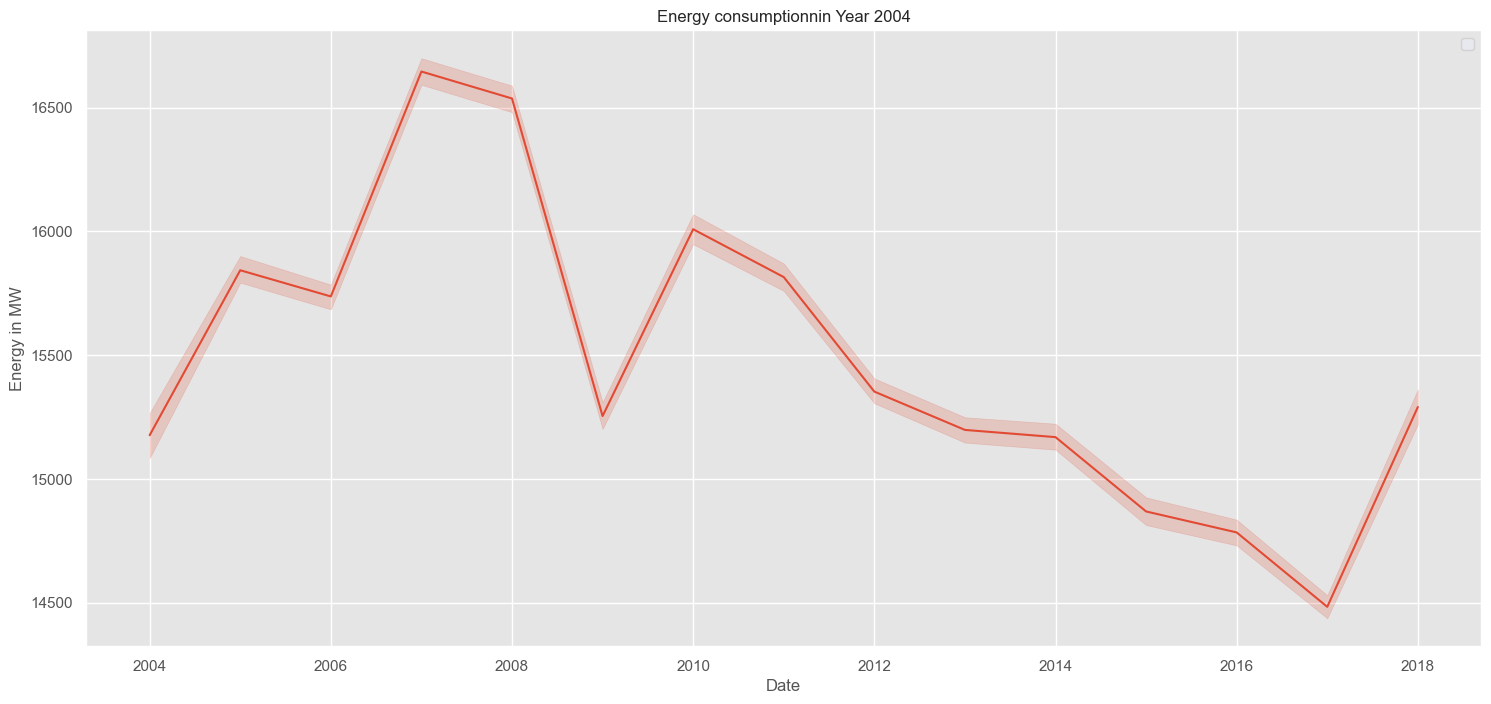

In [34]:
from matplotlib import style
fig = plt.figure()
ax1 = plt.subplot2grid((1, 1),(0, 0))

style.use('ggplot')

sns.lineplot(x=dataset["Year"], y=dataset["AEP_MW"], data=df) # generate a line plot of the year vs power usage
sns.set(rc={'figure.figsize':(15,6)})

plt.title("Energy consumptionnin Year 2004")
plt.xlabel("Date")
plt.ylabel("Energy in MW")
plt.grid(True)
plt.legend()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


[datetime.date(2004, 12, 31), datetime.date(2004, 12, 31), datetime.date(2004, 12, 31), datetime.date(2004, 12, 31), datetime.date(2004, 12, 31), datetime.date(2004, 12, 31), datetime.date(2004, 12, 31), datetime.date(2004, 12, 31), datetime.date(2004, 12, 31), datetime.date(2004, 12, 31), datetime.date(2004, 12, 31), datetime.date(2004, 12, 31), datetime.date(2004, 12, 31), datetime.date(2004, 12, 31), datetime.date(2004, 12, 31), datetime.date(2004, 12, 31), datetime.date(2004, 12, 31), datetime.date(2004, 12, 31), datetime.date(2004, 12, 31), datetime.date(2004, 12, 31), datetime.date(2004, 12, 31), datetime.date(2004, 12, 31), datetime.date(2004, 12, 31), datetime.date(2004, 12, 30), datetime.date(2004, 12, 30), datetime.date(2004, 12, 30), datetime.date(2004, 12, 30), datetime.date(2004, 12, 30), datetime.date(2004, 12, 30), datetime.date(2004, 12, 30), datetime.date(2004, 12, 30), datetime.date(2004, 12, 30), datetime.date(2004, 12, 30), datetime.date(2004, 12, 30), datetime.date

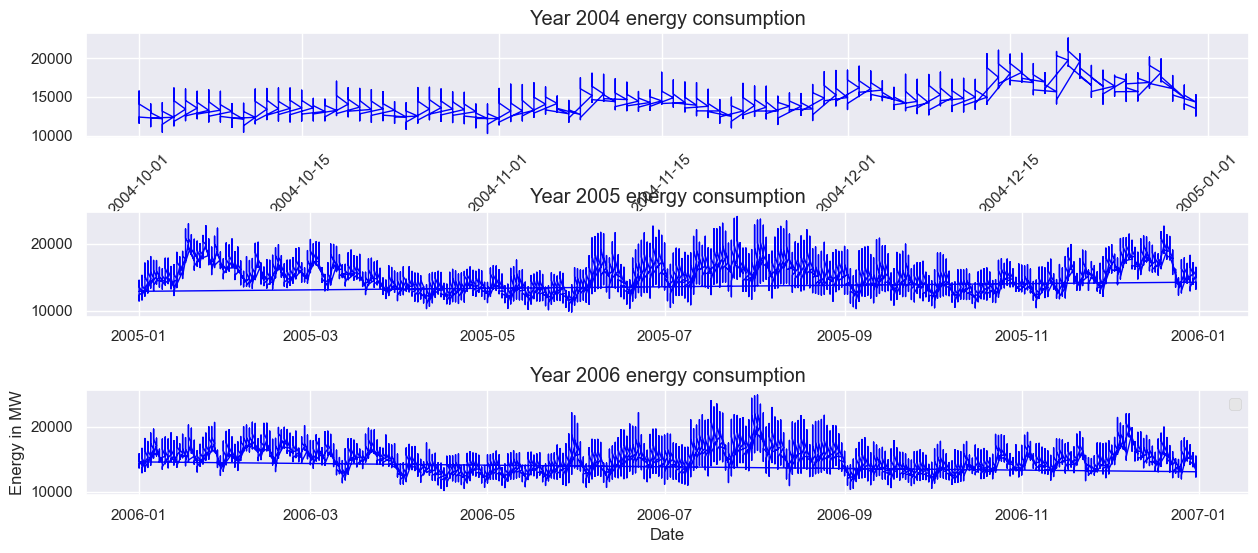

In [35]:
#plot the energy consumption for three years(2004-2006)

fig = plt.figure()
fig.subplots_adjust( hspace=0.7)
ax1= fig.add_subplot(311)
ax2= fig.add_subplot(312)
ax3= fig.add_subplot(313)

style.use('ggplot')
y_2004 = dataset[dataset["Year"] == 2004]["AEP_MW"].to_list()
x_2004 = dataset[dataset["Year"] == 2004]["Date"].to_list()
print(x_2004)

ax1.plot(x_2004, y_2004, color="blue", linewidth= 1)
ax1.set_title("Year 2004 energy consumption")


y_2005 = dataset[dataset["Year"] ==2005]["AEP_MW"].to_list()
x_2005 = dataset[dataset["Year"] ==2005]["Date"].to_list()

ax2.plot(x_2005, y_2005, color="blue", linewidth=1)
ax2.set_title("Year 2005 energy consumption")

y_2006 = dataset[dataset["Year"] ==2006]["AEP_MW"].to_list()
x_2006 = dataset[dataset["Year"] ==2006]["Date"].to_list()
ax3.plot(x_2006, y_2006, color="blue", linewidth=1)
ax3.set_title("Year 2006 energy consumption")

plt.rcParams["figure.figsize"] = (18,8)
# plt.title("Energy consumption")
plt.xlabel("Date")
plt.ylabel("Energy in MW")
plt.grid(True, alpha=1)
plt.legend()


for label in ax1.xaxis.get_ticklabels():
    label.set_rotation(45)

Text(0.5, 1.0, 'energy distribution')

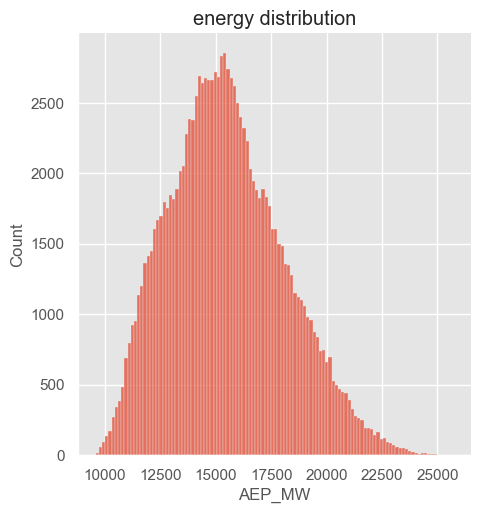

In [36]:
sns.displot(dataset["AEP_MW"]) #disribution of the dataset suggests a normal distribution
plt.title("energy distribution")

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


,AEP_MW,Month,Year,Date,Time,Week,hr
Datetime,,,,,,,
2004-12-31 01:00:00,13478.0,12,2004,2004-12-31,01:00:00,53,1
2004-12-31 02:00:00,12865.0,12,2004,2004-12-31,02:00:00,53,2
2004-12-31 03:00:00,12577.0,12,2004,2004-12-31,03:00:00,53,3
2004-12-31 04:00:00,12517.0,12,2004,2004-12-31,04:00:00,53,4
2004-12-31 05:00:00,12670.0,12,2004,2004-12-31,05:00:00,53,5


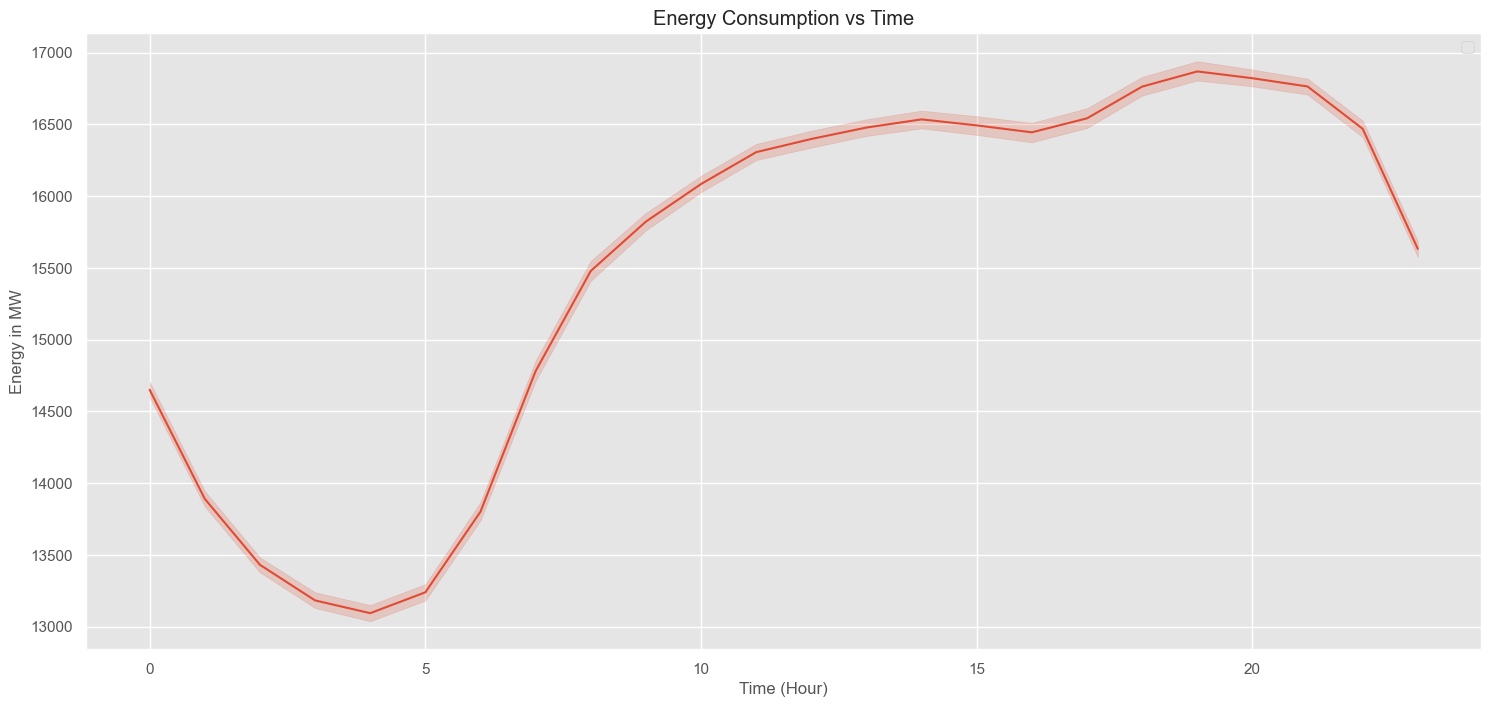

In [37]:
# Convert the "Time" column to just the hour component
dataset["hr"] = dataset["Time"].apply(lambda x: x.hour)

# Plot the line graph
sns.lineplot(x=dataset["hr"], y=dataset["AEP_MW"], data=dataset)

plt.title("Energy Consumption vs Time")
plt.xlabel("Time (Hour)")
plt.ylabel("Energy in MW")
plt.grid(True)
plt.legend()
dataset.head()


In [38]:
daily_energy = dataset.groupby("Date")["AEP_MW"].mean() #average energy per day
daily_energy.head()

Date
2004-10-01    14284.521739
2004-10-02    12999.875000
2004-10-03    12227.083333
2004-10-04    14309.041667
2004-10-05    14439.708333
Name: AEP_MW, dtype: float64

In [39]:
testData = np.array(daily_energy.tail(100)).reshape(-1,1) #select the last 100 rows of AEP_Mw column, convert it to numpy array and reshape it
trainingData = daily_energy.iloc[0:len(daily_energy)-100] #select remaining rows of AEP_Mw column as training data
print(len(trainingData), len(testData), len(trainingData)+len(testData),  daily_energy.size) #check the sliced training and test data make up the original df

trainingSet = np.array(trainingData).reshape(-1,1) # convert trainingSet from df to np array


4955 100 5055 5055


In [40]:
sc = MinMaxScaler(feature_range = (0, 1)) # apply the min-max scaler to normalize the training data
Train = sc.fit_transform(trainingSet)

In [ ]:
# modify the training set to a structure that suits the lstm model: 60 datapoints are used to predict the 61st value 
x_train = []
y_train = []

for i in range(60, len(Train)):
    x_train.append(Train[i-60:i, 0])
    y_train.append(Train[i])
    
x_train, y_train = np.array(x_train), np.array(y_train) #convert the list into np array
print(x_train.shape, y_train.shape) #check the shapes, we need (#, 60, 1)

# Shape should be Number of [Datapoints , Steps , 1 )
# we convert into 3-d Vector or #rd Dimesnsion
x_train = np.reshape(x_train, newshape=(x_train.shape[0], x_train.shape[1], 1))
x_train.shape

(4895, 60) (4895, 1)


(4895, 60, 1)

In [ ]:
#  4 hidden layers each with 50 neurons and a dropout regularisation to avoid overfitting
regressor = Sequential()

# Adding the first LSTM layer and some Dropout regularisation
regressor.add(LSTM(units = 50, return_sequences = True, input_shape = (x_train.shape[1], 1)))
regressor.add(Dropout(0.2))

# Adding a second LSTM layer and some Dropout regularisation
regressor.add(LSTM(units = 50, return_sequences = True))
regressor.add(Dropout(0.2))

# Adding a third LSTM layer and some Dropout regularisation
regressor.add(LSTM(units = 50, return_sequences = True))
regressor.add(Dropout(0.2))

# Adding a fourth LSTM layer and some Dropout regularisation
regressor.add(LSTM(units = 50))
regressor.add(Dropout(0.2))

# Adding the output layer
regressor.add(Dense(units = 1))

# Compiling the RNN
regressor.compile(optimizer = 'adam', loss = 'mean_squared_error') #use the adam optimizer and the mean squared error for the loss


In [44]:
regressor.fit(x_train, y_train, epochs = 20, batch_size = 32)

Epoch 1/20
153/153 [==============================] - 38s 172ms/step - loss: 0.0253
Epoch 2/20
153/153 [==============================] - 24s 154ms/step - loss: 0.0180
Epoch 3/20
153/153 [==============================] - 27s 178ms/step - loss: 0.0172
Epoch 4/20
153/153 [==============================] - 27s 180ms/step - loss: 0.0161
Epoch 5/20
153/153 [==============================] - 28s 182ms/step - loss: 0.0158
Epoch 6/20
153/153 [==============================] - 18s 120ms/step - loss: 0.0155
Epoch 7/20
153/153 [==============================] - 25s 162ms/step - loss: 0.0153
Epoch 8/20
153/153 [==============================] - 21s 135ms/step - loss: 0.0134
Epoch 9/20
153/153 [==============================] - 23s 150ms/step - loss: 0.0115
Epoch 10/20
153/153 [==============================] - 33s 214ms/step - loss: 0.0099
Epoch 11/20
153/153 [==============================] - 26s 169ms/step - loss: 0.0091
Epoch 12/20
153/153 [==============================] - 23s 151ms/step - lo

In [46]:
# here the first 60 rows of training data which are not used to train the model 
# are concatenated with the test data
inputs = np.concatenate((trainingSet[0:60,:], testData), axis=0) 

In [47]:
inputs = sc.transform(inputs) # normalize the test data

#arrange the test data to a structure as required by the lstm model
x_test = [] 
for i in range(60, 160):
    x_test.append(inputs[i-60:i])

x_test = np.array(x_test) #convert to array

predicted_load = regressor.predict(x_test) #use the test data to predict the load via the model developed
predicted_load = sc.inverse_transform(predicted_load) #inverse transform the output for clear comparison with actual load data

4/4 [==============================] - 4s 38ms/step


In [48]:
dates = daily_energy.tail(100).index # store the dates(index) of the test data 

comparison_df = pd.DataFrame(data = {
    "Data": dates, # first column 
    "True value": daily_energy.tail(100).values, # second column: True value from original data
    "Predicted value": [x[0] for x in predicted_load ] # predicted value from the lstm model
}) #create a df of predictions and actual values

comparison_df.set_index("Data") 

,True value,Predicted value
Data,,
2018-04-26,13157.791667,16503.140625
2018-04-27,12964.000000,12833.465820
2018-04-28,12237.583333,14720.385742
2018-04-29,12156.791667,12364.639648
2018-04-30,13443.500000,13297.770508
...,...,...
2018-07-30,15368.083333,14900.285156
2018-07-31,15180.291667,16135.687500
2018-08-01,15151.166667,15428.264648


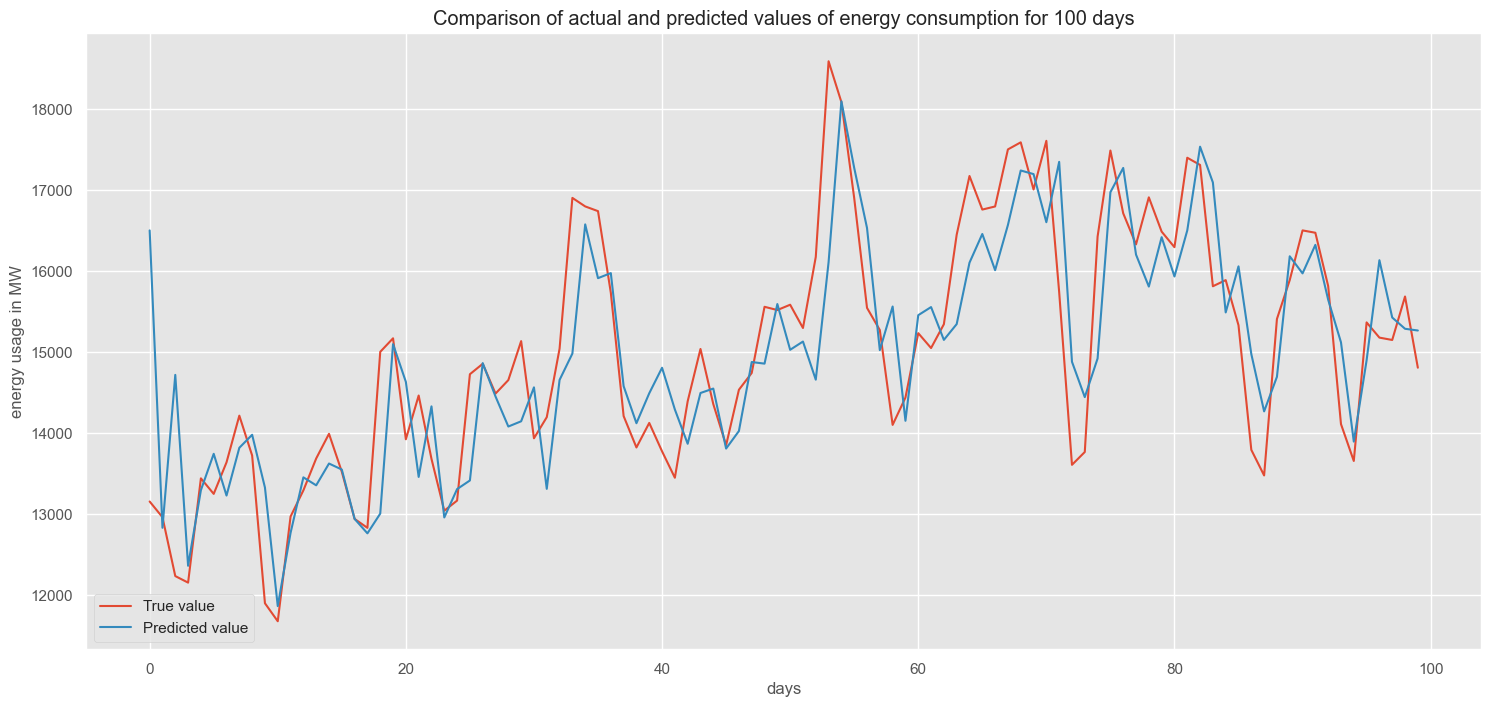

In [55]:
fig = plt.figure() #visualization of the accuracy of the plot
ax1 = fig.add_subplot(111)

ax1.plot(comparison_df.index, comparison_df["True value"], label="True value")
ax1.plot(comparison_df.index,  comparison_df["Predicted value"], label="Predicted value")

plt.xlabel("days")
plt.ylabel("energy usage in MW")
plt.title("Comparison of actual and predicted values of energy consumption for 100 days")
plt.legend(loc="lower left")
plt.show()